In [1]:
#### mv packages ####
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(['cuda:1', 'cuda:0'])

#### data ####
data = d.Preprocessor(
    tcga_project='TCGA-BRCA',
    tcga_dir=dataset_dir/'tcga',
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv',
    metadata_subtype_col = 'paper_BRCA_Subtype_PAM50',
    
    # counts
    apply_DESeq_norm=True, 
    log_transform=True,
    scale_method='standard',

    # etc
    y_col = 'subtype',
    drop = {'subtype':['Normal', 'Primary Tumor']},
    max_subset = 120,
)
dataset = d.GraphDataset(data)
databatch = d.get_toy_databatch(dataset, generator)

# #### Device() ####
# device = cuda:6

# #### Preprocessor() ####
# log0_method              log1p                    str
# class_weights            (6,)                     Tensor (cuda:6)
# edge_index               (2, 32798)               Tensor (cuda:6)
# edge_attr                (32798, 16)              Tensor (cuda:6)
# gene_counts              (4383, 562)              DataFrame
# metadata                 (562, 3)                 DataFrame
# relation                 (32798, 18)              DataFrame
# node_id_map              4383                     dict
# mask_list                305                      list
# mask                     (4383, 305)              Tensor (cuda:6)
# x                        (562, 4383, 1)           Tensor (cuda:6)
# y                        (562,)                   Tensor (cuda:6)
# y_labels                 6                        list
# num_samples              562                      int
# num_nodes                4383                     int


----

In [2]:
from modules.model import SequentialModel

#### packages ####
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, GCNConv

#### typing ####
from torch import Tensor
from pandas import DataFrame
from typing import Literal, Union

In [3]:
class SetPooling(nn.Module):
    def __init__(self, mask:Tensor, out_channels:int=None, *args, **kwargs):
        '''
        pools nodes into sets using weights generated from self.mask.
        mask: (num_nodes, num_sets)
        '''
        super().__init__(*args, **kwargs)

        # format to enable projection
        self.mask = mask.unsqueeze(0) # --> (1, num_nodes, num_sets)

    def forward(self, x:Tensor):
        '''
        forward pass, pooling x to z.
        x: (batch_size, num_nodes, num_features)
        z: (batch_size, num_sets, num_features)
        '''
        # compute weight
        weight = self._compute_weight(x) # (batch_size, num_sets, num_nodes)

        # pool (sum) into set: (b,s,n) @ (b,n,F)
        z = torch.bmm(weight, x) # (batch_size, num_sets, num_features)

        return z
    
    def _compute_weight(self, x:Tensor):
        '''
        computes weight from self.mask and x (if applicable). To be changed in child class
        '''
        pass

In [4]:
class AddSetPooling(SetPooling):
    def __init__(self, mask:Tensor, out_channels:int=None, *args, **kwargs):
        '''
        pools nodes into sets by addition
        mask: (num_nodes, num_sets)
        '''
        super().__init__(mask, out_channels, *args, **kwargs)
    
    def _compute_weight(self, x:Tensor):
        '''
        returns expanded, transposed mask
        '''
        batch_size = x.shape[0]

        # format mask as 'weight' for bmm
        weight = self.mask # --> (1, num_nodes, num_sets)
        weight = weight.transpose(1,2) # --> (1, num_sets, num_nodes)
        weight = weight.expand(batch_size, -1, -1) # --> (batch_size, num_sets, num_nodes)

        return weight      

In [27]:
class SignedAttentionSetPooling(SetPooling):
    def __init__(self, mask:Tensor, out_channels:int, hidden_dims:list=[], act_fn=nn.LeakyReLU(), end_fn=None, eps:float=1e-8, *args, **kwargs):
        '''
        signed attention-weighted set pooling.
        mask: (num_nodes, num_sets)
        '''
        self.eps = eps # small num to prevent division by 0
        super().__init__(mask, out_channels, *args, **kwargs)

        # define linear transform layer for learnable attention scores
        num_sets = mask.shape[1]
        
        # self.lin = nn.Linear(out_channels, num_sets)
        self.lin = SequentialModel(
            in_channels=out_channels,
            out_channels=num_sets,
            layer_class=nn.Linear,
            hidden_dims=hidden_dims,
            act_fn=act_fn,
            end_fn=end_fn
        )

    def _compute_weight(self, x:Tensor):
        '''
        computes weight as tanh(scores)/L1norm(tanh(scores))
        '''
        # get scores via (b,n,F) @ (b,F,s); mask --> (batch_size, num_nodes, num_sets)
        scores = self.lin(x)
        scores = scores * self.mask

        # compute weight via tanh activation / L1norm
        scores = torch.tanh(scores)
        # L1norm = torch.sum(torch.abs(scores), dim=1, keepdim=True)
        # weight = scores / (L1norm + self.eps)
        weight = scores

        # transpose for bmm
        weight = weight.transpose(1,2) # --> (batch_size, num_sets, num_nodes)

        return weight

---

In [28]:
class FiLM(nn.Module):
    def __init__(self, in_channels:int, out_channels:int, bias:bool=True, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.weight = nn.Parameter(torch.randn(in_channels, out_channels))
        self.bias = nn.Parameter(torch.randn())

---

In [29]:
class Node2SetEncoder(nn.Module):
    def __init__(
        self, 
        num_node_features:int, # in_channels
        embedding_size:int, # out_channels
        mask:Tensor, # (num_nodes, num_sets)
        pooling_class:SetPooling,
        encoder_class:Union[nn.Module, MessagePassing],
        pooling_kwargs:dict={},  
        encoder_kwargs:dict={}, 
        *args, 
        **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.num_nodes, self.num_sets = mask.shape

        self.node_encoder = SequentialModel(
            in_channels=num_node_features,
            out_channels=embedding_size,
            layer_class=encoder_class,
            **encoder_kwargs
        )

        self.node2set = pooling_class(
            out_channels=embedding_size,
            mask=mask,
            **pooling_kwargs
        )

        self.set2sample = pooling_class(
            out_channels=embedding_size,
            mask=torch.ones(self.num_sets,1),
            **pooling_kwargs
        )

    def forward(self, x:Tensor, return_set_embedding:bool=True, *args, **kwargs):
        # x: (batch_size * num_nodes, embedding_size), from PyG DataBatch
        batch_size = int(x.shape[0] / self.num_nodes)

        # get node embedding
        x = self.node_encoder(x, *args, **kwargs) # (batch_size * num_nodes, embedding_size)
        x = x.view(batch_size, self.num_nodes, -1) # (batch_size, num_nodes, embedding_size)

        # node to set embedding
        set_embedding = self.node2set(x) # (batch_size, num_sets, embedding_size)

        # set to sample embedding
        x = self.set2sample(set_embedding) # (batch_size, 1, embedding_size)
        x = x.squeeze(1) # (batch_size, embedding_size)

        if return_set_embedding:
            return x, set_embedding
        return x

In [30]:
# class Set2NodeDecoder(nn.Module):
#     def __init__(
#         self,
#         num_node_features:int, # out_channels
#         embedding_size:int, # in_channels
#         mask:Tensor,
#         pooling_class:SetPooling,
#         decoder_class:nn.Module,
#         pooling_kwargs:dict={}, 
#         decoder_kwargs:dict={},
#         *args,
#         **kwargs
#     ):
#         super().__init__(*args, **kwargs)
#         self.mask = mask.T.unsqueeze(0) # (1, num_sets, num_nodes)
#         _, self.num_sets, self.num_nodes = self.mask.shape
#         self.set_tokens = nn.Parameter(torch.randn(self.num_sets, embedding_size))
#         nn.init.uniform_(self.set_tokens, -1, 1.0)

#         self.mask_encoder = SequentialModel(
#             in_channels=self.num_nodes,
#             out_channels=embedding_size,
#             layer_class=decoder_class,
#             **decoder_kwargs
#         )
#         self.FiLM = SequentialModel(
#             in_channels=2*embedding_size,
#             out_channels=2*embedding_size,
#             layer_class=decoder_class,
#             **decoder_kwargs
#         )

#         self.set_decoder = SequentialModel(
#             in_channels=embedding_size,
#             out_channels=embedding_size,
#             layer_class=decoder_class,
#             **decoder_kwargs
#         )

#         self.set2node = pooling_class(
#             out_channels = embedding_size,
#             mask=mask.T, # (num_sets, num_nodes)
#             **pooling_kwargs
#         )

#         self.node_decoder = SequentialModel(
#             in_channels=embedding_size,
#             out_channels=num_node_features,
#             layer_class=decoder_class,
#             **decoder_kwargs
#         )

#     def forward(self, z:Tensor, return_set_embedding:bool=True):
#         # z: (batch_size, embedding_size)
#         batch_size = z.shape[0]

#         # FiLM
#         z_exp = z.unsqueeze(1).repeat(1, self.num_sets, 1) # --> (batch_size, num_sets, embedding_size)

#         mask_emb = self.mask_encoder(self.mask)
#         mask_exp = mask_emb.expand(batch_size,-1,-1)
        
#         FiLM_input = torch.cat([mask_exp, z_exp], dim=-1)
#         gamma, beta = self.FiLM(FiLM_input).chunk(2, dim=-1)
        
#         set_tokens = self.set_tokens.unsqueeze(0).expand(batch_size, -1, -1)
#         z_mod = gamma * set_tokens + beta
#         z_mod = F.layer_norm(z_mod, z_mod.shape[-1:])

#         # get set embedding
#         set_embedding = self.set_decoder(z_mod) 
#         set_embedding = F.layer_norm(set_embedding, set_embedding.shape[-1:])

#         # set2node pooling, reconstruct node embeddings
#         x = self.set2node(set_embedding) # --> (batch_size, num_nodes, embedding_size)
#         x = F.layer_norm(x, x.shape[-1:])
#         x = self.node_decoder(x)
        
#         # flatten to original shape (batch_size * num_nodes, embedding_size)
#         x = x.view(batch_size * self.num_nodes, -1)

#         if return_set_embedding:
#             return x, set_embedding
#         else:
#             return x

In [31]:
class Set2NodeDecoder(nn.Module):
    def __init__(
        self,
        num_node_features:int, # out_channels
        embedding_size:int, # in_channels
        mask:Tensor,
        pooling_class:SetPooling,
        decoder_class:nn.Module,
        pooling_kwargs:dict={}, 
        decoder_kwargs:dict={},
        *args,
        **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.mask = mask.T.unsqueeze(0) # (1, num_sets, num_nodes)
        _, self.num_sets, self.num_nodes = self.mask.shape
        self.embedding_size = embedding_size

        self.sample2set = SequentialModel(
            in_channels=embedding_size,
            out_channels=self.num_sets * embedding_size,
            layer_class=decoder_class,
            **decoder_kwargs
        )

        self.mask_encoder = SequentialModel(
            in_channels=self.num_nodes,
            out_channels=embedding_size,
            layer_class=decoder_class,
            **decoder_kwargs
        )

        self.FiLM = SequentialModel(
            in_channels=2*embedding_size,
            out_channels=2*embedding_size,
            layer_class=decoder_class,
            **decoder_kwargs
        )

        self.set_decoder = SequentialModel(
            in_channels=embedding_size,
            out_channels=embedding_size,
            layer_class=decoder_class,
            **decoder_kwargs
        )

        self.set2node = pooling_class(
            out_channels = embedding_size,
            mask=mask.T, # (num_sets, num_nodes)
            **pooling_kwargs
        )

        self.node_decoder = SequentialModel(
            in_channels=embedding_size,
            out_channels=num_node_features,
            layer_class=decoder_class,
            **decoder_kwargs
        )

    def mod(self, x:Tensor, gamma:Tensor, beta:Tensor):
        return gamma * x + beta

    def forward(self, z:Tensor, return_set_embedding:bool=True):
        # z: (batch_size, embedding_size)
        batch_size = z.shape[0]

        # embed mask for context
        mask_emb = self.mask_encoder(self.mask)
        mask_exp = mask_emb.expand(batch_size,-1,-1)

        # transform sample into set space + mask context
        z = self.sample2set(z).view(batch_size, self.num_sets, self.embedding_size)

        # FiLM
        FiLM_input = torch.cat([mask_exp, z], dim=-1)
        gamma, beta = self.FiLM(FiLM_input).chunk(2, dim=-1)
        z = self.mod(z+mask_exp, gamma, beta)
        # z = z + mask_exp

        # get set embedding
        set_embedding = self.set_decoder(z) 

        # set2node pooling, reconstruct node embeddings
        x = self.set2node(set_embedding) # --> (batch_size, num_nodes, embedding_size)
        x = F.layer_norm(x, x.shape[-1:])
        x = self.node_decoder(x)

        # flatten to original shape (batch_size * num_nodes, embedding_size)
        x = x.view(batch_size * self.num_nodes, -1)

        if return_set_embedding:
            return x, set_embedding
        else:
            return x

In [32]:
n2s = Node2SetEncoder(
    num_node_features=data.num_node_features,
    embedding_size=128,
    mask=data.mask,
    pooling_class=SignedAttentionSetPooling,
    encoder_class=nn.Linear
)

print(databatch.x.shape)

z, set = n2s(databatch.x, edge_index=databatch.edge_index)
print(z.shape, set.shape)

s2n = Set2NodeDecoder(
    num_node_features=data.num_node_features,
    embedding_size=128,
    mask=data.mask,
    pooling_class=SignedAttentionSetPooling,
    decoder_class=nn.Linear
)

x_hat, set_hat = s2n(z)
print(x_hat.shape, set_hat.shape)


torch.Size([280512, 1])
torch.Size([64, 128]) torch.Size([64, 305, 128])
torch.Size([280512, 1]) torch.Size([64, 305, 128])


In [33]:
z.unsqueeze(1).shape

torch.Size([64, 1, 128])

In [34]:
class PathwayAutoencoder(nn.Module):
    def __init__(
        self,
        num_node_features:int,
        embedding_size:int,
        mask:Tensor,
        pooling_class:SetPooling,
        encoder_class:Union[nn.Module, MessagePassing],
        decoder_class:nn.Module,
        pooling_kwargs:dict={}, 
        encoder_kwargs:dict={},
        decoder_kwargs:dict={},  
        *args,
        **kwargs
    ):
        super().__init__(*args, **kwargs)
        self.num_nodes, self.num_sets = mask.shape

        self.encoder = Node2SetEncoder(
            num_node_features=num_node_features,
            embedding_size=embedding_size,
            mask=mask,
            pooling_class=pooling_class,
            encoder_class=encoder_class,
            pooling_kwargs=pooling_kwargs,
            encoder_kwargs=encoder_kwargs
        )

        self.decoder = Set2NodeDecoder(
            num_node_features=num_node_features,
            embedding_size=embedding_size,
            mask=mask,
            pooling_class=pooling_class,
            decoder_class=decoder_class,
            pooling_kwargs=pooling_kwargs,
            decoder_kwargs=decoder_kwargs          
        )

    def forward(self, x:Tensor, return_set_itmes=True, *args, **kwargs):
        # encode sample embedding (z) and set embedding
        z, set_emb = self.encoder(x, *args, **kwargs)

        # decode sample embedding to reconstructions
        x_recon, set_recon = self.decoder(z)

        if return_set_itmes:
            return x_recon, set_recon, set_emb
        else:
            return x_recon
        


In [35]:
pathae = PathwayAutoencoder(
    num_node_features=data.num_node_features,
    embedding_size=128,
    mask=data.mask,
    pooling_class=SignedAttentionSetPooling,
    encoder_class=GCNConv,
    decoder_class=nn.Linear
)

pathae(databatch.x, False, edge_index=databatch.edge_index).shape

torch.Size([280512, 1])

---

In [36]:
from modules.data import GraphDataset
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader
from torch.nn.modules.loss import _Loss
from torch import Generator
from tqdm import tqdm

import sklearn.metrics
from torch_geometric.nn import GATv2Conv

In [37]:
class Loader():
    def __init__(self, dataset:GraphDataset, generator:Generator, batch_size:int=16, val_size:int=0.15, test_size:int=0.15):
        # format Xy as dataset
        self.dataset = dataset

        # get split sizes
        val_size = int(val_size * len(self.dataset))
        test_size = int(test_size * len(self.dataset))
        train_size = int(len(self.dataset) - val_size - test_size)

        # train test split
        train_dataset, val_dataset, test_dataset = random_split(self.dataset, [train_size, val_size, test_size], generator=generator)

        # get dataloaders
        self.train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, generator=generator)
        self.test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, generator=generator)

In [38]:
class Trainer():
    def __init__(self, model, loader:Loader, num_epochs:int, loss_fn:_Loss, optimizer_class:torch.optim.Optimizer=torch.optim.Adam, optimizer_kwargs:dict={}, report_metrics=['loss'], verbose:bool=False, autorun:bool=True):
        # assign inst vars
        self.model = model # should be a predefined model
        self.loader = loader
        self.num_epochs = num_epochs
        self.loss_fn = loss_fn
        self.optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)
        self.report_metrics = report_metrics
        self.verbose = verbose
        
        if autorun:
            self.run()

    def run(self, mode:Literal['classify', 'reconstruct']=None):
        self.mode = mode

        # verbose, use tqdm
        if self.verbose == True:
            pbar = tqdm(range(self.num_epochs))
        else:
            pbar = range(self.num_epochs)

        # train, val loop
        self.dev_metrics = {}

        for epoch in pbar:
            # training
            train_metrics = self._run_phase('train', self.loader.train_loader)

            # validating
            val_metrics = self._run_phase('eval', self.loader.val_loader)

            # record training/validation
            self.dev_metrics[epoch] = {'train': train_metrics, 'val': val_metrics}

            # get reports
            train_report = self._generate_report(train_metrics, self.report_metrics)
            val_report = self._generate_report(val_metrics, self.report_metrics)

            # update pbar with report
            if self.verbose == True:
                epoch_report = f'Epoch {epoch:<8}' + f'Train: {train_report}' + 8*' ' + f'Val: {val_report}'
                pbar.set_postfix_str(epoch_report)

        # test
        self.test_metrics = self._run_phase('eval', self.loader.test_loader)

        # print test report
        if self.verbose == True:
            test_report = self._generate_report(self.test_metrics, self.report_metrics)
            tqdm.write(f'Test\t {test_report}\n')

    def _generate_report(self, metrics:dict, report_metrics:list):
        # generate report
        report = (4*' ').join(
            f'{metric}={metrics[metric]:<.4f}'
            for metric in report_metrics
            if metric in metrics
        )

        return report

    def _run_phase(self, mode:Literal['train','eval'], dataloader:DataLoader):
        # init batch_log
        batch_log = {
            'batch_idx':0,
            'num_batches':len(dataloader),
            'loss':0,
            'batch':[], # model input; used for custom metrics
            'out':[] # model output; used for custom metrics
        }

        # train mode
        if mode == 'train':
            self.model.train()
            for batch in dataloader:
                self.optimizer.zero_grad()
                loss, out = self._compute_loss(batch) 
                loss.backward()
                self.optimizer.step()
                batch_log = self._update_batch_log(batch_log, loss, batch, out)

            self.batch_log = batch_log # debugging

        # eval mode
        else:
            self.model.eval()
            with torch.no_grad():
                for batch in dataloader:
                    loss, out = self._compute_loss(batch)
                    batch_log = self._update_batch_log(batch_log, loss, batch, out)

            # self.batch_log = batch_log # debugging

        # compute metrics
        metrics = self._compute_metrics(batch_log)

        return metrics
    
    def _update_batch_log(self, batch_log:dict, loss:Tensor, batch:Union[Tensor,tuple], out:Union[Tensor,tuple]):
        # increment batch, loss
        batch_log['batch_idx'] += 1
        batch_log['loss'] += loss.item()

        # detach batch (inputs), outputs
        batch = self._detach_items(batch)
        out = self._detach_items(out)

        # append batch, outputs
        batch_log['batch'].append(batch)
        batch_log['out'].append(out)

        return batch_log
    
    def _detach_items(self, item):
        # single tensor
        if isinstance(item, Tensor):
            return item.detach().cpu()

        # list/tuple of tensors
        elif isinstance(item, (tuple, list)):
            return type(item)(self._detach_items(i) for i in item)

        # dict
        elif isinstance(item, dict):
            return {key: self._detach_items(value) for key, value in item.items()}
        
        # PyG DataBatch or other class with .x
        elif hasattr(item, 'x'):
            x = self._detach_items(item.x)
            y = self._detach_items(getattr(item, 'y', None))
            return {'x': x, 'y': y} if y is not None else {'x':x}
        
        # fallback
        return item

    #### change in child objects if needed: ####

    def _compute_loss(self, batch): # change in child
        # default, assume 1 item/Tensor (x)
        x = y = batch

        # extract x,y if applicable
        if isinstance(batch, (tuple,list)): # tuple, list
            if len(batch) > 0:
                x = batch[0]
            if len(batch) > 1:
                y = batch[1]
        elif isinstance(batch, dict): # dict
            x = batch.get('x', batch)
            y = batch.get('y', x)
        elif hasattr(batch, 'x'): # PyG DataBath or other class with .x
            x = batch.x
            y = getattr(batch, 'y', x)

        # assign y as x if mode=reconstruct
        if self.mode == 'reconstruct':
            y = x
        
        # get model output
        out = self.model(x)

        # compute loss
        loss = self.loss_fn(out, y)

        return loss, out
    
    def _compute_metrics(self, batch_log:dict): # change in child
        # init
        metrics = {}

        # compute metrics
        metrics['loss'] = batch_log['loss']/batch_log['num_batches']

        return metrics

In [39]:
class PathwayAETrainer(Trainer):
    def __init__(self, alpha:float=0.5, *args, **kwargs):
        self.alpha = alpha
        super().__init__(*args, **kwargs)
        
    def _compute_loss(self, batch):
        # extract x
        if isinstance(batch, (tuple, list)):
            x = batch[0]
        elif isinstance(batch, dict):
            x = batch.get('x', batch)
        elif hasattr(batch, 'x'):
            x = batch.x
            edge_index = batch.edge_index
        else:
            x = batch

        # forward pass
        x_recon, set_recon, set_emb = self.model(x, edge_index=edge_index)

        # compute reconstruction loss
        loss_x = self.loss_fn(x_recon, x)
        loss_set = self.loss_fn(set_recon, set_emb)
        loss = self.alpha*loss_x + (1-self.alpha)*loss_set

        # tuple outputs
        out = (x_recon, set_recon, set_emb)

        return loss, out

In [40]:
pathae = PathwayAutoencoder(
    num_node_features=data.num_node_features,
    embedding_size=64,
    mask=data.mask,
    pooling_class=SignedAttentionSetPooling,
    encoder_class=nn.Linear,
    decoder_class=nn.Linear,

    pooling_kwargs={'hidden_dims':[128,128]},
    encoder_kwargs={'hidden_dims':[128,128]},
    decoder_kwargs={'hidden_dims':[128,128]}
)

pathae_loader = Loader(
    dataset=dataset,
    generator=generator,
    batch_size=128
)

pathae_trainer = PathwayAETrainer(
    model=pathae,
    loader=pathae_loader,
    num_epochs=100,
    loss_fn=nn.MSELoss(),
    optimizer_kwargs={'lr':0.001},
    verbose=True,
    alpha=0.5
)

100%|██████████| 100/100 [00:55<00:00,  1.79it/s, Epoch 99      Train: loss=0.3430        Val: loss=0.4104]

Test	 loss=0.5014



---

In [41]:
# get x
x = pathae_trainer.batch_log['batch'][0]['x']

# get dims
num_nodes = pathae.num_nodes
batch_size = int(x.shape[0] / num_nodes)

# reshape x, get others
x = x.view(batch_size, num_nodes)
x_recon = pathae_trainer.batch_log['out'][0][0].view(batch_size, num_nodes)
set_recon = pathae_trainer.batch_log['out'][0][1][0] # last 0 gets 0th sample
set_emb = pathae_trainer.batch_log['out'][0][2][0] # last 0 gets 0th sample

In [42]:
import seaborn as sns

<Axes: >

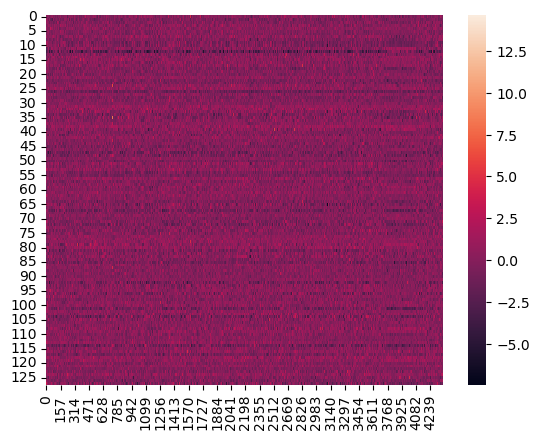

In [43]:
sns.heatmap(x, vmin=x.min(), vmax=x.max())

<Axes: >

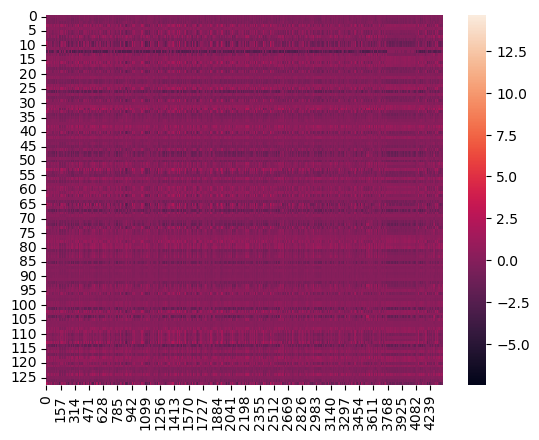

In [44]:
sns.heatmap(x_recon, vmin=x.min(), vmax=x.max())

In [45]:
print(x.min(), x.max())
print(x_recon.min(), x_recon.max())

tensor(-7.4526) tensor(14.6442)
tensor(-3.1208) tensor(2.8173)


---

<Axes: >

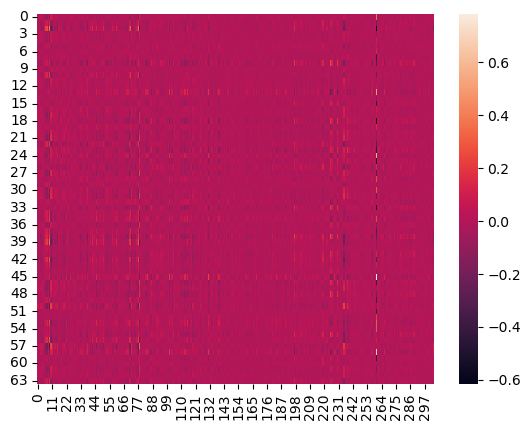

In [46]:
sns.heatmap(set_emb.T, vmin=set_emb.min(), vmax=set_emb.max())

<Axes: >

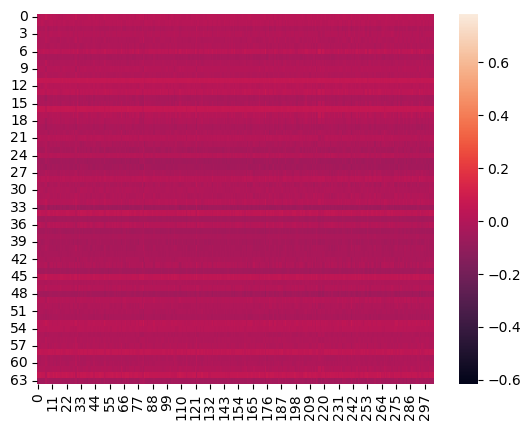

In [47]:
sns.heatmap(set_recon.T, vmin=set_emb.min(), vmax=set_emb.max())

In [48]:
print(set_emb.min(), set_emb.max())
print(set_recon.min(), set_recon.max())

tensor(-0.6148) tensor(0.7827)
tensor(-0.0888) tensor(0.0834)
